In [1]:
# Controlling cpu usage
import os
os.environ["NUMBA_NUM_THREADS"] = "6"
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"

In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np

In [ ]:
# Use the raw data for evaluation
brain_vascular = sc.read_h5ad("../brain_vascular.h5ad")
adata = brain_vascular.raw.to_adata()

In [ ]:

# Adding mitochondrial gene annotation
adata.var["mt"] = adata.var["feature_name"].str.upper().str.startswith("MT-")
# Calculating QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

adata_qc = adata[
    (adata.obs["n_genes_by_counts"] > 300) &
    (adata.obs["n_genes_by_counts"] < 8000) &
    (adata.obs["total_counts"] < 55000) &
    (adata.obs["pct_counts_mt"] < 15),
    :
].copy()

# Adding n_counts to obs for Geneformer input
adata_qc.obs["n_counts"] = adata_qc.obs["total_counts"]

adata_qc.write_h5ad("../metrics/geneformer/input/geneformer_input.h5ad")

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from geneformer import TranscriptomeTokenizer
from geneformer import EmbExtractor

In [ ]:
# Tokenizing the data for Geneformer
tk = TranscriptomeTokenizer(
    custom_attr_name_dict={
        "author_cell_type": "author_cell_type"
    },
    nproc=8,
    model_version='V2'
)
tk.tokenize_data(
    "../metrics/geneformer/input",
    output_directory="../metrics/geneformer/tokenized",
    output_prefix="geneformer_tokenized",
    file_format="h5ad"
)

Tokenizing /data/slurm/huangjr/cmml/metrics/geneformer/input/geneformer_input.h5ad


100%|██████████| 121/121 [02:08<00:00,  1.06s/it]
/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


/data/slurm/huangjr/cmml/metrics/geneformer/input/geneformer_input.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [ ]:
# Embeddings extraction
embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=0,
    emb_mode="cls",
    emb_layer=-1,
    emb_label=["author_cell_type"],
    max_ncells=None,
    forward_batch_size=64,
    nproc=16,
    model_version="V2"
)

embs = embex.extract_embs("../models/Geneformer/Geneformer-V2-104M",
                          "../metrics/geneformer/tokenized/geneformer_tokenized.dataset",
                          "../metrics/geneformer/embeddings",
                          "geneformer_embs"
                          )

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from emb_eva import evaluate_embeddings
import pandas as pd

In [ ]:
# evaluating extracted embeddings
embs = pd.read_csv("../metrics/geneformer/embeddings/geneformer_embs.csv", 
                   index_col=0)

In [5]:
# Separate embeddings and labels
label_col = "author_cell_type"

X = embs.drop(columns=[label_col])
y = embs[label_col]

# Train/test split
X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.2,
    random_state=42,
    stratify=y.values
)

In [ ]:
# Evaluate with logistic regression
results = []
result_logreg, y_pred_logreg, clf_logreg = evaluate_embeddings(
    X_train_emb=X_train_emb,
    y_train=y_train,
    X_test_emb=X_test_emb,
    y_test=y_test,
    model_name="Geneformer",
    classifier="logreg",
    random_state=42
)
results.append(result_logreg)

benchmark_df = pd.DataFrame(results)
benchmark_df

/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=4', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,classifier,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n_train,n_test,embedding_dim
0,Geneformer,logreg,0.95878,0.960404,0.96557,0.962829,0.95905,0.95878,0.958776,49197,12300,768


In [8]:
# Classification report
from sklearn.metrics import classification_report               

report = classification_report(
    y_test,
    y_pred_logreg,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
Arterial,0.927744,0.949756,0.938621,1433.00000
Astrocyte,0.992780,0.985663,0.989209,279.00000
Capillary,0.911504,0.870611,0.890589,1538.00000
Excitatory_Neuron,0.986509,0.983193,0.984848,595.00000
Inhibitory_Neuron,0.974843,0.965732,0.970266,321.00000
Meningeal_Fibroblast,0.991886,0.983903,0.987879,497.00000
Microglia,0.987303,0.986301,0.986802,1971.00000
Oligodendrocyte,0.995663,0.993939,0.994801,1155.00000
Oligodendrocyte_Precursor_Cell,1.000000,1.000000,1.000000,114.00000
Pericyte,0.937913,0.962060,0.949833,738.00000


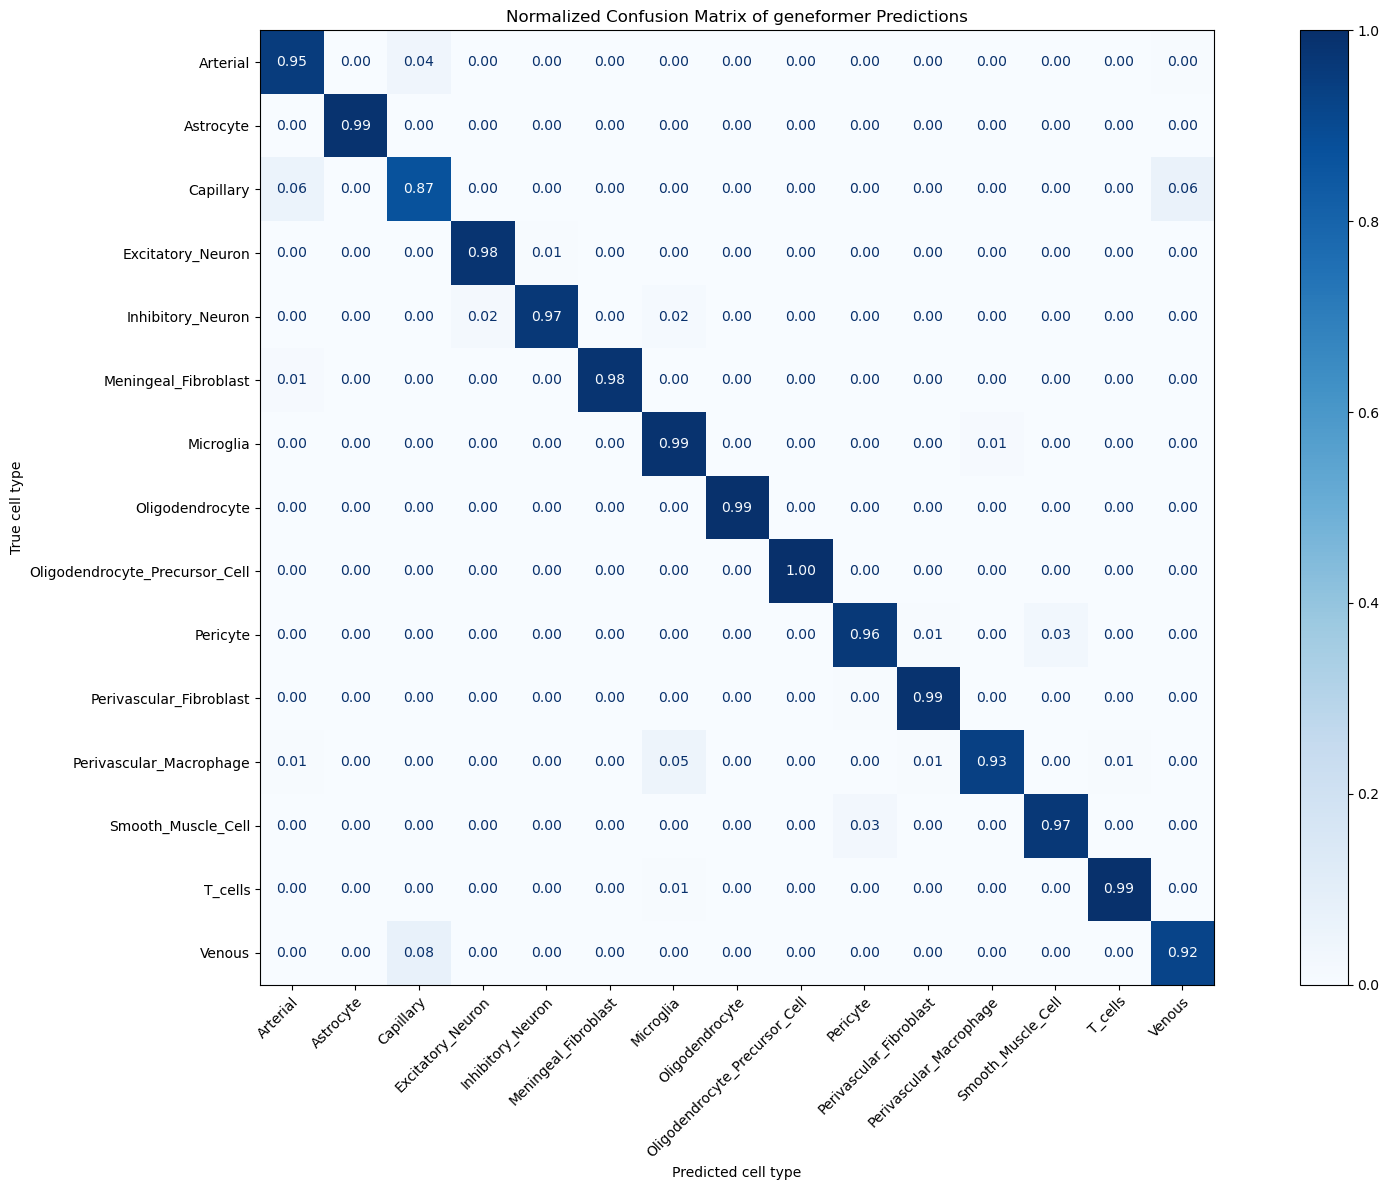

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

class_names = sorted(pd.Series(y_test).unique())

# Normalized confusion matrix
cm_norm = confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=class_names,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(18, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

ax.set_title("Normalized Confusion Matrix of geneformer Predictions")
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("True cell type")

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_rotation_mode("anchor")

plt.tight_layout()
plt.savefig("../metrics/geneformer_conf_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
